In [1]:
import glob
from pathlib import Path


import pandas as pnd
import cobra



from helper_functions import *

# Format raw tables

## 04_streptococcus

In [2]:
SD1 = pnd.read_excel('04_streptococcus/tables/41564_2022_1208_MOESM4_ESM.xlsx', sheet_name='Supplementary_data_1')
high_saturation = SD1[SD1['Tn-Seq libraries saturation (%)3']>35]
strains_04 = high_saturation['Common lab name']
print(len(strains_04), list(strains_04))

17 ['PG01', 'PG02', 'PG04', 'PG06', 'PG12', 'PG13', 'PG15', 'PG16', 'PG25', 'PG27', 'PG28', 'PG29', 'TIGR4-AC316', 'D39-AC1770', 'Taiwan19F-14', 'BHN97', 'CT22F']


In [3]:
tradis_exps = pnd.read_excel(f'04_streptococcus/tables/41564_2022_1208_MOESM4_ESM.xlsx', sheet_name='Supplementary_data_6')
tradis_exps = tradis_exps.drop_duplicates('locus_tag', keep='first')
tradis_exps = tradis_exps.set_index('locus_tag', drop=True, verify_integrity=True).reset_index()
tradis_exps = tradis_exps[['Strain', 'Binomial Call', 'locus_tag']]
tradis_exps = tradis_exps.rename({'Strain': 'strain', 'Binomial Call': 'experimental', 'locus_tag': 'gid'}, axis=1)
tradis_exps['dataset'] = '04_streptococcus'

# rename strains
tradis_exps['strain'] = tradis_exps['strain'].replace({'CT-22F': 'CT22F', 'Taiwan-19F': 'Taiwan19F-14'})

# focus on 17 high-coverage strains
tradis_exps = tradis_exps[tradis_exps['strain'].isin(strains_04)]  

# retain only genes for which there's a clear 'Binomial Call':
tradis_exps = tradis_exps.dropna()
tradis_exps = tradis_exps[tradis_exps['experimental'] != 'Uncertain']

# and binarize using bool type:
tradis_exps['experimental'] = tradis_exps['experimental'].replace({'Essential': True, 'Non-Essential': False})

tradis_exps.to_csv('04_streptococcus/tables/tradis_exp.csv')
tradis_exps

,strain,experimental,gid,dataset
0,PG01,True,EQH15_00005,04_streptococcus
1,PG01,True,EQH15_00010,04_streptococcus
2,PG01,True,EQH15_00015,04_streptococcus
3,PG01,False,EQH15_00020,04_streptococcus
4,PG01,True,EQH15_00025,04_streptococcus
...,...,...,...,...
72541,PG25,False,ES300_11080,04_streptococcus
72542,PG25,False,ES300_11085,04_streptococcus
72543,PG25,False,ES300_11095,04_streptococcus
72544,PG25,False,ES300_11100,04_streptococcus


# 05_pseudomonas

In [4]:
suppl_table_03 = pnd.read_excel('05_pseudomonas/tables/pnas.1900570116.sd03.xlsx')
suppl_table_03 = suppl_table_03.set_index('Gene ID', drop=True, verify_integrity=True)
# format strain names
for index, row in suppl_table_03.iterrows():
    if row['Strain'] == 'BWH005': suppl_table_03.loc[index, 'Strain'] = 'BWHPSA005'
    if row['Strain'] == 'BWH013': suppl_table_03.loc[index, 'Strain'] = 'BWHPSA013'
    if row['Strain'] == 'BWH015': suppl_table_03.loc[index, 'Strain'] = 'BWHPSA015'
    if row['Strain'] == 'PA14': suppl_table_03.loc[index, 'Strain'] = 'UCBPP-PA14'

suppl_table_03

,Strain,LB Essential Call (FWER-adjustment),LB Essential Call (FDR-adjustment),LB Essential Call (TRANSIT HMM),M9 Essential Call (FWER-adjustment),M9 Essential Call (FDR-adjustment),M9 Essential Call (TRANSIT HMM)
Gene ID,,,,,,,
Q018_00033,BWHPSA005,NE,NE,GA,NE,NE,NE
Q018_00046,BWHPSA005,NE,NE,GA,NE,NE,NE
Q018_00051,BWHPSA005,NE,NE,GA,NE,NE,NE
Q018_00063,BWHPSA005,NE,NE,GA,NE,NE,NE
Q018_00076,BWHPSA005,NE,NE,GA,NE,NE,NE
...,...,...,...,...,...,...,...
Q026_04217,BWHPSA013,E,E,ES,E,E,ES
Q026_02953,BWHPSA013,NE,NE,NE,NE,NE,NE
Q026_02893,BWHPSA013,NE,E,NE,NE,NE,NE


In [5]:
# use the FWER-adjustment (more conservative: fewer false-positives)
tradis_exps = suppl_table_03[['Strain', 'LB Essential Call (FWER-adjustment)']].copy()
tradis_exps = tradis_exps.reset_index()
tradis_exps['dataset'] = '05_pseudomonas'
tradis_exps = tradis_exps.rename(columns ={'Gene ID': 'gid', 'Strain': 'strain', 'LB Essential Call (FWER-adjustment)': 'experimental'})
tradis_exps['experimental'] = tradis_exps['experimental'].replace({'NE': False, 'E': True})

tradis_exps.to_csv('05_pseudomonas/tables/tradis_exp.csv')
tradis_exps

,gid,strain,experimental,dataset
0,Q018_00033,BWHPSA005,False,05_pseudomonas
1,Q018_00046,BWHPSA005,False,05_pseudomonas
2,Q018_00051,BWHPSA005,False,05_pseudomonas
3,Q018_00063,BWHPSA005,False,05_pseudomonas
4,Q018_00076,BWHPSA005,False,05_pseudomonas
...,...,...,...,...
53283,Q026_04217,BWHPSA013,True,05_pseudomonas
53284,Q026_02953,BWHPSA013,False,05_pseudomonas
53285,Q026_02893,BWHPSA013,False,05_pseudomonas
53286,Q026_01136,BWHPSA013,False,05_pseudomonas


# 06_pseudomonas

In [6]:
# use the FWER-adjustment (more conservative: fewer false-positives)
tradis_exps = suppl_table_03[['Strain', 'M9 Essential Call (FWER-adjustment)']].copy()
tradis_exps = tradis_exps.reset_index()
tradis_exps['dataset'] = '06_pseudomonas'
tradis_exps = tradis_exps.rename(columns ={'Gene ID': 'gid', 'Strain': 'strain', 'M9 Essential Call (FWER-adjustment)': 'experimental'})
tradis_exps['experimental'] = tradis_exps['experimental'].replace({'NE': False, 'E': True})

tradis_exps.to_csv('06_pseudomonas/tables/tradis_exp.csv')
tradis_exps

,gid,strain,experimental,dataset
0,Q018_00033,BWHPSA005,False,06_pseudomonas
1,Q018_00046,BWHPSA005,False,06_pseudomonas
2,Q018_00051,BWHPSA005,False,06_pseudomonas
3,Q018_00063,BWHPSA005,False,06_pseudomonas
4,Q018_00076,BWHPSA005,False,06_pseudomonas
...,...,...,...,...
53283,Q026_04217,BWHPSA013,True,06_pseudomonas
53284,Q026_02953,BWHPSA013,False,06_pseudomonas
53285,Q026_02893,BWHPSA013,False,06_pseudomonas
53286,Q026_01136,BWHPSA013,False,06_pseudomonas


# merge formatted tables

In [7]:
tradis_exps = []
for dataset in ['04_streptococcus', '05_pseudomonas', '06_pseudomonas']:
    tradis_exp = pnd.read_csv(f'{dataset}/tables/tradis_exp.csv', index_col=0)
    tradis_exp['dataset'] = dataset
    tradis_exps.append(tradis_exp)
tradis_exps = pnd.concat(tradis_exps).reset_index(drop=True)

tradis_exps = tradis_exps.sort_values(['dataset', 'strain', 'gid']).reset_index(drop=True)
#tradis_exps = tradis_exps.set_index('gid', drop=True, verify_integrity=True)
tradis_exps.to_csv('tables/tradis_exps.csv')
tradis_exps

,strain,experimental,gid,dataset
0,BHN97,True,EQH44_00005,04_streptococcus
1,BHN97,True,EQH44_00010,04_streptococcus
2,BHN97,True,EQH44_00015,04_streptococcus
3,BHN97,False,EQH44_00020,04_streptococcus
4,BHN97,True,EQH44_00025,04_streptococcus
...,...,...,...,...
137915,X13273,False,Q013_06584,06_pseudomonas
137916,X13273,False,Q013_06587,06_pseudomonas
137917,X13273,False,Q013_06588,06_pseudomonas
137918,X13273,False,Q013_06590,06_pseudomonas


# get simulations

## define main functions

In [8]:
def apply_medium_file(model, file):
    
    # reset all the exchanges:
    for r in model.reactions: 
        if len(r.metabolites)==1 and list(r.metabolites)[0].id.rsplit('_', 1)[-1][0]=='e':
            r.bounds = (0, 1000)
    
    if   '/gempipe/' in file: 
        with open(file.split('/gempipe/', 1)[0] + f'/gempipe/medium_gempipe.json') as f:
            medium_json = eval(f.read())
            for exr_id, lower_bound in medium_json['exchanges'].items():
                model.reactions.get_by_id(exr_id).lower_bound = lower_bound
                
    elif '/gempipe_rf/' in file: 
        with open(file.split('/gempipe_rf/', 1)[0] + f'/gempipe_rf/medium_gempipe_rf.json') as f:
            medium_json = eval(f.read())
            for exr_id, lower_bound in medium_json['exchanges'].items():
                model.reactions.get_by_id(exr_id).lower_bound = lower_bound
                                
    elif '/carveme/' in file: 
        medium_df = pnd.read_csv(file.split('/carveme/', 1)[0] + f'/carveme/medium_carveme.tsv', sep='\t')
        for compound in medium_df['compound']:
            exr_id = 'EX_' + compound + '_e'
            try: model.reactions.get_by_id(exr_id).lower_bound = -1000
            except: pass # exr was not included during reconstruction despite explicitly mentioned in 'medium_carveme.tsv' (and no errors were raised!)
    
    elif '/gapseq/' in file: 
        medium_df = pnd.read_csv(file.split('/gapseq/', 1)[0] + f'/gapseq/medium_gapseq_dedup.csv')
        for compound, flux in zip(list(medium_df['compounds']), list(medium_df['maxFlux'])):
            exr_id = 'EX_' + compound + '_e0'
            try: model.reactions.get_by_id(exr_id).lower_bound = -flux
            except: pass # exr was not included during reconstruction despite explicitly mentioned in 'medium_carveme.tsv' (and no errors were raised!)
          
    elif '/bactabolize/' in file: 
        with open(file.split('/bactabolize/', 1)[0] + f'/bactabolize/medium_bactabolize.json') as f:
            medium_json = eval(f.read())
            for exr_id, lower_bound in medium_json['exchanges'].items():
                model.reactions.get_by_id(exr_id).lower_bound = lower_bound
            # add "atmosphere" params, not included in the json recipe
            model.reactions.get_by_id('EX_co2_e').lower_bound = -1000
            model.reactions.get_by_id('EX_o2_e').lower_bound = -1000
                                
    elif '/bactabolize_3070/' in file: 
        with open(file.split('/bactabolize_3070/', 1)[0] + f'/bactabolize_3070/medium_bactabolize.json') as f:
            medium_json = eval(f.read())
            for exr_id, lower_bound in medium_json['exchanges'].items():
                model.reactions.get_by_id(exr_id).lower_bound = lower_bound
            # add "atmosphere" params, not included in the json recipe
            model.reactions.get_by_id('EX_co2_e').lower_bound = -1000
            model.reactions.get_by_id('EX_o2_e').lower_bound = -1000
                

In [9]:
def get_essentiality_results_df(files):
    
    
    results_df = [] 
    for file in files:
        
        # get the strain ID:
        strain_id = Path(file).stem
        strain_id = strain_id.replace('_model', '')
        if '-draft' in strain_id: 
            continue    # Skip gapseq draft models

        # load the model:
        if   file.endswith('.xml'): 
            model = cobra.io.read_sbml_model(file)
        elif file.endswith('.json'): 
            model = cobra.io.load_json_model(file)
    
        
        # set the medium
        apply_medium_file(model, file)
        res = model.optimize()
        if res.objective_value < 0.001 or res.status=='infeasible':
            print('▮')   # loading bar


        # simulate deletions
        deletion_results = cobra.flux_analysis.single_gene_deletion(model)
        for index, row in deletion_results.iterrows(): 
            gid = list(row['ids'])[0]
            essential = row['growth'] < 0.001 or row['status'] == 'infeasible'
            results_df.append({
                'strain': strain_id,
                'gid': gid,
                'essential': essential,
                'growth': row['growth'],
                'status': row['status'],
            })

            
        print('▯', end='')  # loading bar

    results_df = pnd.DataFrame.from_records(results_df)
    return results_df

## main run 

In [10]:
%%capture --no-stdout


df_list = []
for dataset in ['04_streptococcus', '05_pseudomonas', '06_pseudomonas']:
    
    for tool in ['gempipe', 'gempipe_rf', 'carveme', 'gapseq', 'bactabolize']: 
        
        if   tool=='gempipe':     globber = f'{dataset}/tools_runs/gempipe/output/strain_models_gf/*.json'
        elif tool=='gempipe_rf':  globber = f'{dataset}/tools_runs/gempipe_rf/output/strain_models_gf/*.json'
        elif tool=='carveme':     globber = f'{dataset}/tools_runs/carveme/output/*.xml'
        elif tool=='gapseq':      globber = f'{dataset}/tools_runs/gapseq/output/*/*.xml'
        elif tool=='bactabolize': 
            #globber = f'{dataset}/tools_runs/bactabolize/gapfilled/*.json'
            globber = f'{dataset}/tools_runs/bactabolize_3070/gapfilled/*.json'
                
        print(dataset, tool, end=': ') 
        res = parallelizer(globber, get_essentiality_results_df, nthreads=17)
        print()
        
        res['tool'] = tool
        res['dataset'] = dataset
        df_list.append(res)
        
df_dataset = pnd.concat(df_list)
df_dataset = df_dataset.reset_index(drop=True)
df_dataset.to_csv(f'tables/tradis_sims.csv')

04_streptococcus gempipe: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
04_streptococcus gempipe_rf: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
04_streptococcus carveme: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
04_streptococcus gapseq: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
04_streptococcus bactabolize: ▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯▯
05_pseudomonas gempipe: ▯▯▯▯▯▯▯▯▯
05_pseudomonas gempipe_rf: ▯▯▯▯▯▯▯▯▯
05_pseudomonas carveme: ▯▯▯▯▯▯▯▯▯
05_pseudomonas gapseq: ▯▯▯▯▯▯▯▯▯
05_pseudomonas bactabolize: ▯▯▯▯▯▯▯▯▯
06_pseudomonas gempipe: ▯▯▯▯▯▯▯▯▯
06_pseudomonas gempipe_rf: ▯▯▯▯▯▯▯▯▯
06_pseudomonas carveme: ▯▯▯▯▯▯▯▯▯
06_pseudomonas gapseq: ▯▯▯▯▯▯▯▯▯
06_pseudomonas bactabolize: ▯▯▯▯▯▯▯▯▯


# Define match

In [11]:
tradis_sims = pnd.read_csv(f'tables/tradis_sims.csv', index_col=0)
tradis_sims

,strain,gid,essential,growth,status,tool,dataset
0,PG02,EQH16_03845,False,0.754003,optimal,gempipe,04_streptococcus
1,PG02,EQH16_08305,False,0.754003,optimal,gempipe,04_streptococcus
2,PG02,EQH16_01965,False,0.754003,optimal,gempipe,04_streptococcus
3,PG02,EQH16_08560,False,0.754003,optimal,gempipe,04_streptococcus
4,PG02,EQH16_06490,False,0.754003,optimal,gempipe,04_streptococcus
...,...,...,...,...,...,...,...
185668,CF77,Q092_04056,True,0.000000,optimal,bactabolize,06_pseudomonas
185669,CF77,Q092_06125,True,0.000000,optimal,bactabolize,06_pseudomonas
185670,CF77,Q092_05095,True,0.000000,optimal,bactabolize,06_pseudomonas
185671,CF77,Q092_03887,False,0.893774,optimal,bactabolize,06_pseudomonas


In [12]:
dataset_to_tradisexps = {}
for dataset, indexes in tradis_exps.groupby('dataset').groups.items():
    dataset_to_tradisexps[dataset] = tradis_exps.iloc[indexes, ].copy().set_index('gid', drop=True, verify_integrity=True)

In [13]:
# create a match dataframe:
match_df = tradis_sims.copy()


match_df['experimental'] = None
match_df['call'] = None

for index, row in match_df.iterrows(): 
    
    try: exp = dataset_to_tradisexps[row['dataset']].loc[row['gid'], 'experimental']
    except: exp = 'unknown'
    match_df.loc[index, 'experimental'] = exp
    
    sim = row['essential']
    if exp=='unknown': match_df.loc[index, 'call'] = 'unknown'
    else:
        if   sim==True and exp==True:   match_df.loc[index, 'call'] = 'TP'
        elif sim==False and exp==False: match_df.loc[index, 'call'] = 'TN'
        elif sim==True and exp==False:  match_df.loc[index, 'call'] = 'FP'
        elif sim==False and exp==True:  match_df.loc[index, 'call'] = 'FN'

match_df

,strain,gid,essential,growth,status,tool,dataset,experimental,call
0,PG02,EQH16_03845,False,0.754003,optimal,gempipe,04_streptococcus,False,TN
1,PG02,EQH16_08305,False,0.754003,optimal,gempipe,04_streptococcus,unknown,unknown
2,PG02,EQH16_01965,False,0.754003,optimal,gempipe,04_streptococcus,False,TN
3,PG02,EQH16_08560,False,0.754003,optimal,gempipe,04_streptococcus,unknown,unknown
4,PG02,EQH16_06490,False,0.754003,optimal,gempipe,04_streptococcus,False,TN
...,...,...,...,...,...,...,...,...,...
185668,CF77,Q092_04056,True,0.000000,optimal,bactabolize,06_pseudomonas,False,FP
185669,CF77,Q092_06125,True,0.000000,optimal,bactabolize,06_pseudomonas,True,TP
185670,CF77,Q092_05095,True,0.000000,optimal,bactabolize,06_pseudomonas,False,FP
185671,CF77,Q092_03887,False,0.893774,optimal,bactabolize,06_pseudomonas,False,TN


# suppl table creation

In [24]:

#suppl_table = match_df[match_df['call'] != 'unknown'].copy().reset_index(drop=True)
suppl_table = match_df.copy().reset_index(drop=True)
suppl_table = suppl_table.rename(columns={'gid': 'gene ID', 'essential': 'simulation', })
suppl_table = suppl_table[['dataset', 'strain', 'gene ID', 'tool', 'simulation', 'experimental', 'call']]

suppl_table.to_excel("tables/Supplementary Table 2.xlsx")
suppl_table

,dataset,strain,gene ID,tool,simulation,experimental,call
0,04_streptococcus,PG02,EQH16_03845,gempipe,False,False,TN
1,04_streptococcus,PG02,EQH16_08305,gempipe,False,unknown,unknown
2,04_streptococcus,PG02,EQH16_01965,gempipe,False,False,TN
3,04_streptococcus,PG02,EQH16_08560,gempipe,False,unknown,unknown
4,04_streptococcus,PG02,EQH16_06490,gempipe,False,False,TN
...,...,...,...,...,...,...,...
185668,06_pseudomonas,CF77,Q092_04056,bactabolize,True,False,FP
185669,06_pseudomonas,CF77,Q092_06125,bactabolize,True,True,TP
185670,06_pseudomonas,CF77,Q092_05095,bactabolize,True,False,FP
185671,06_pseudomonas,CF77,Q092_03887,bactabolize,False,False,TN


# Generate figures

In [14]:

%load_ext autoreload
%aimport plots_biolog_tradis
%autoreload 1

In [15]:
from plots_biolog_tradis import *

In [16]:
tool_colors = {
    "gempipe_pan": "C5",
    "gempipe": "C0",
    "gempipe_rf": "C4",
    "carveme": "C1",
    "gapseq": "C2",
    "bactabolize_pan": "C8",
    'bactabolize_pan_3070': 'C9',
    "bactabolize": "C3",
    #'bactabolize_3070': 'C6',
}

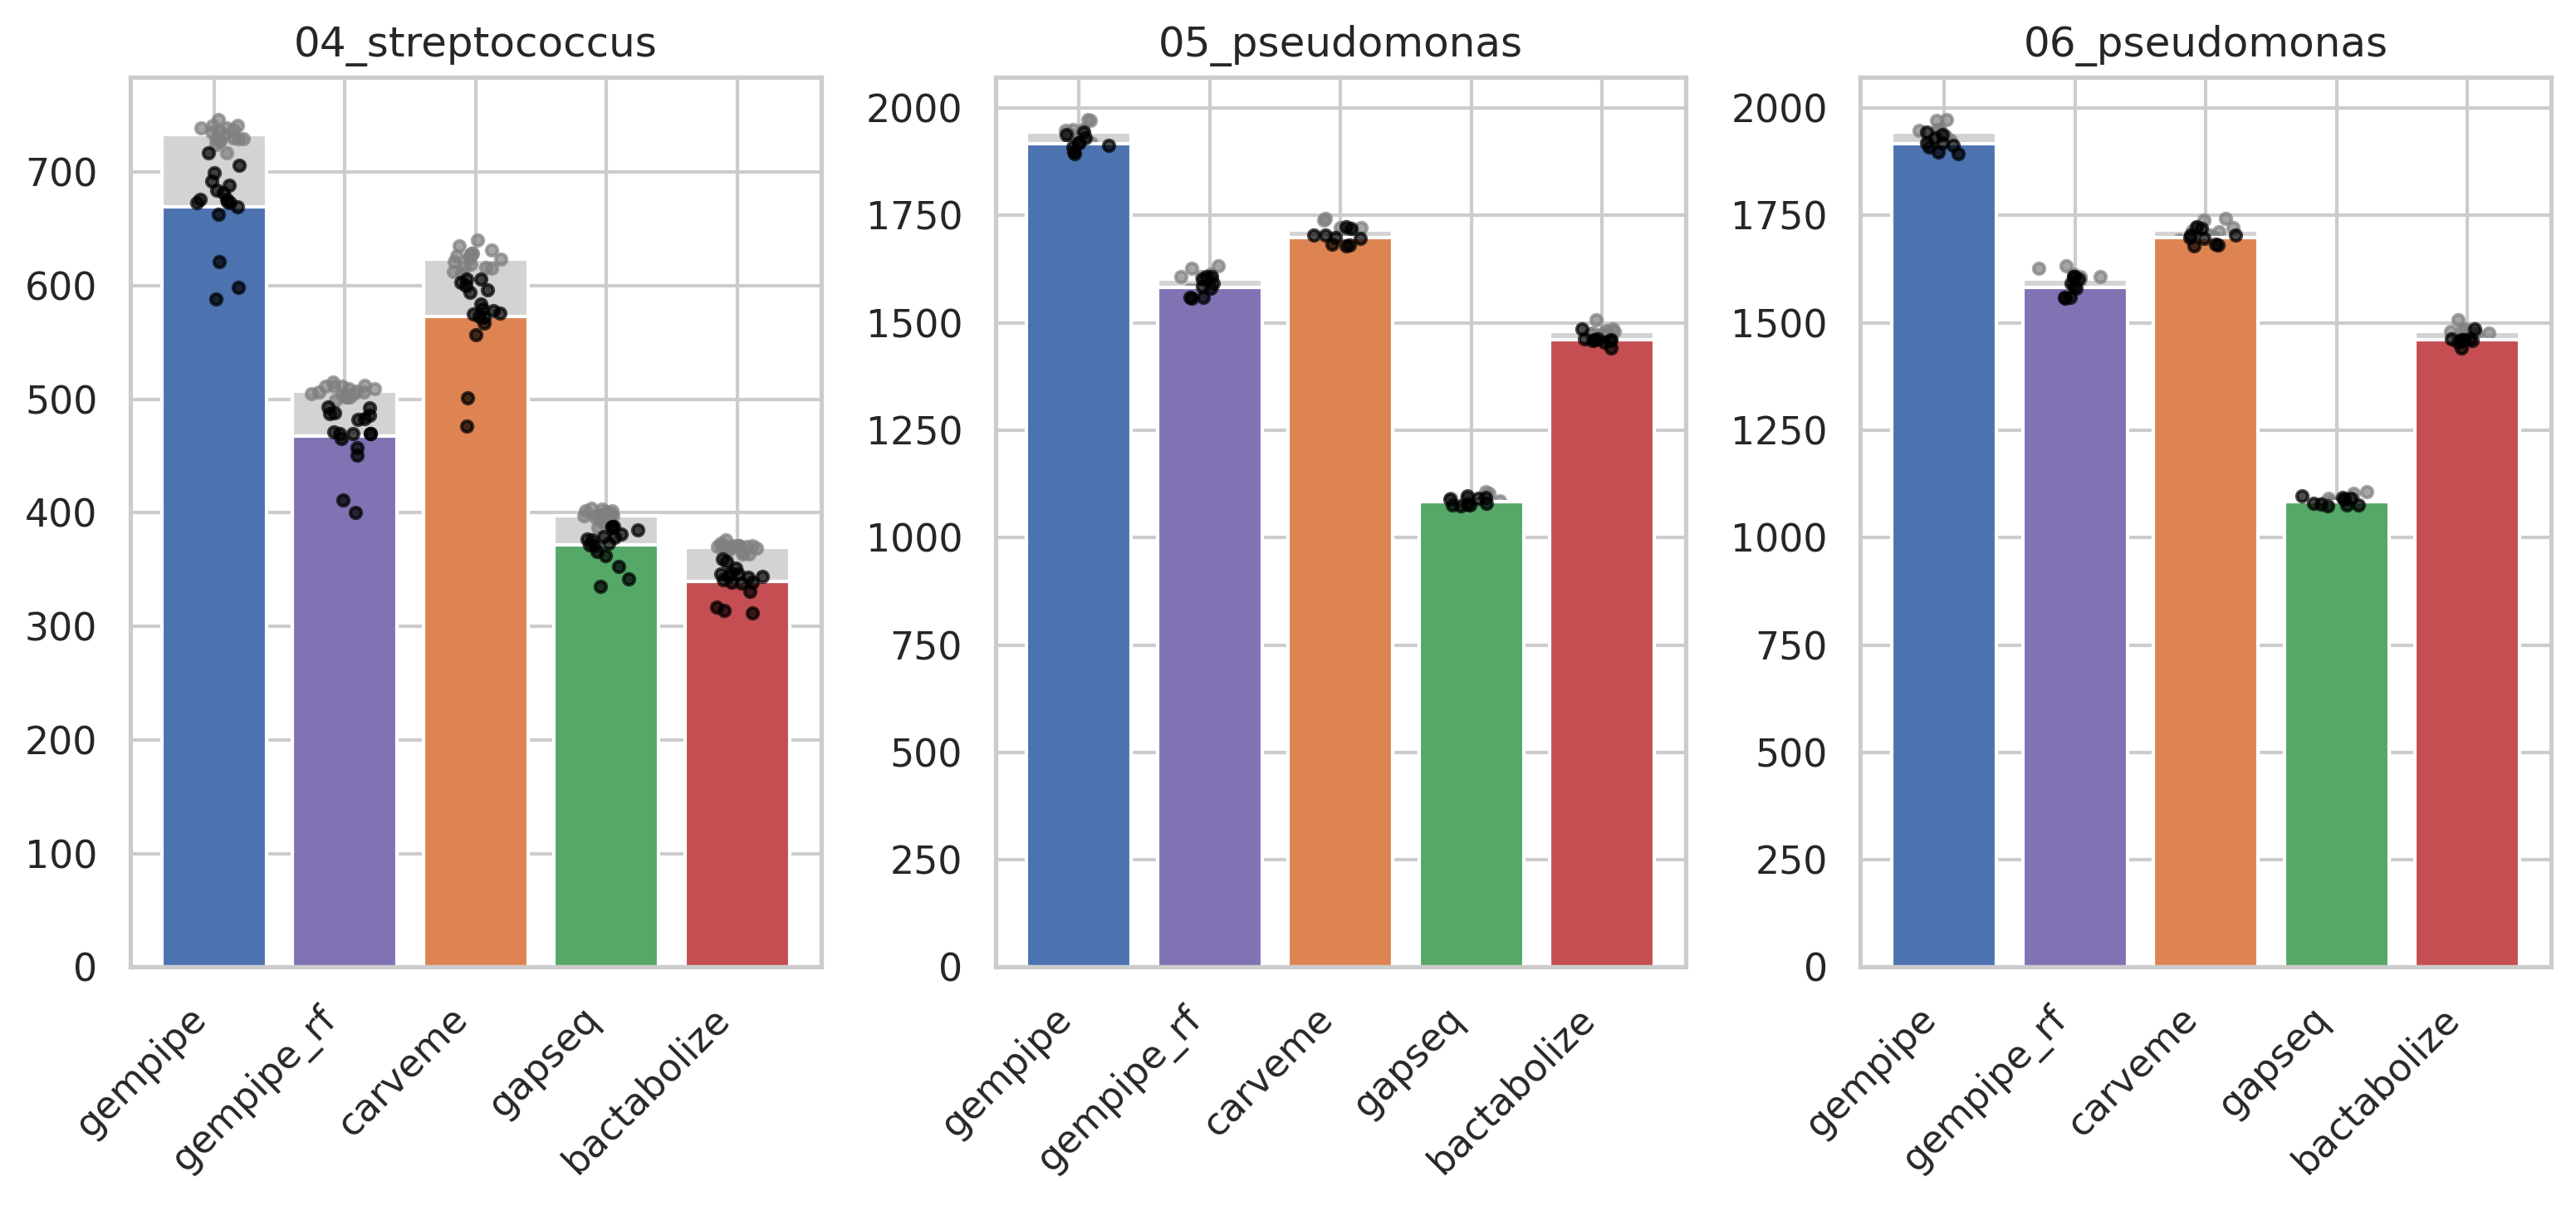

In [17]:
fig = plot_predictions(match_df, tool_colors, focus_on='gid', exclude=[], alltools=True)
fig.savefig("figures/Figure 4A.png", dpi=300)

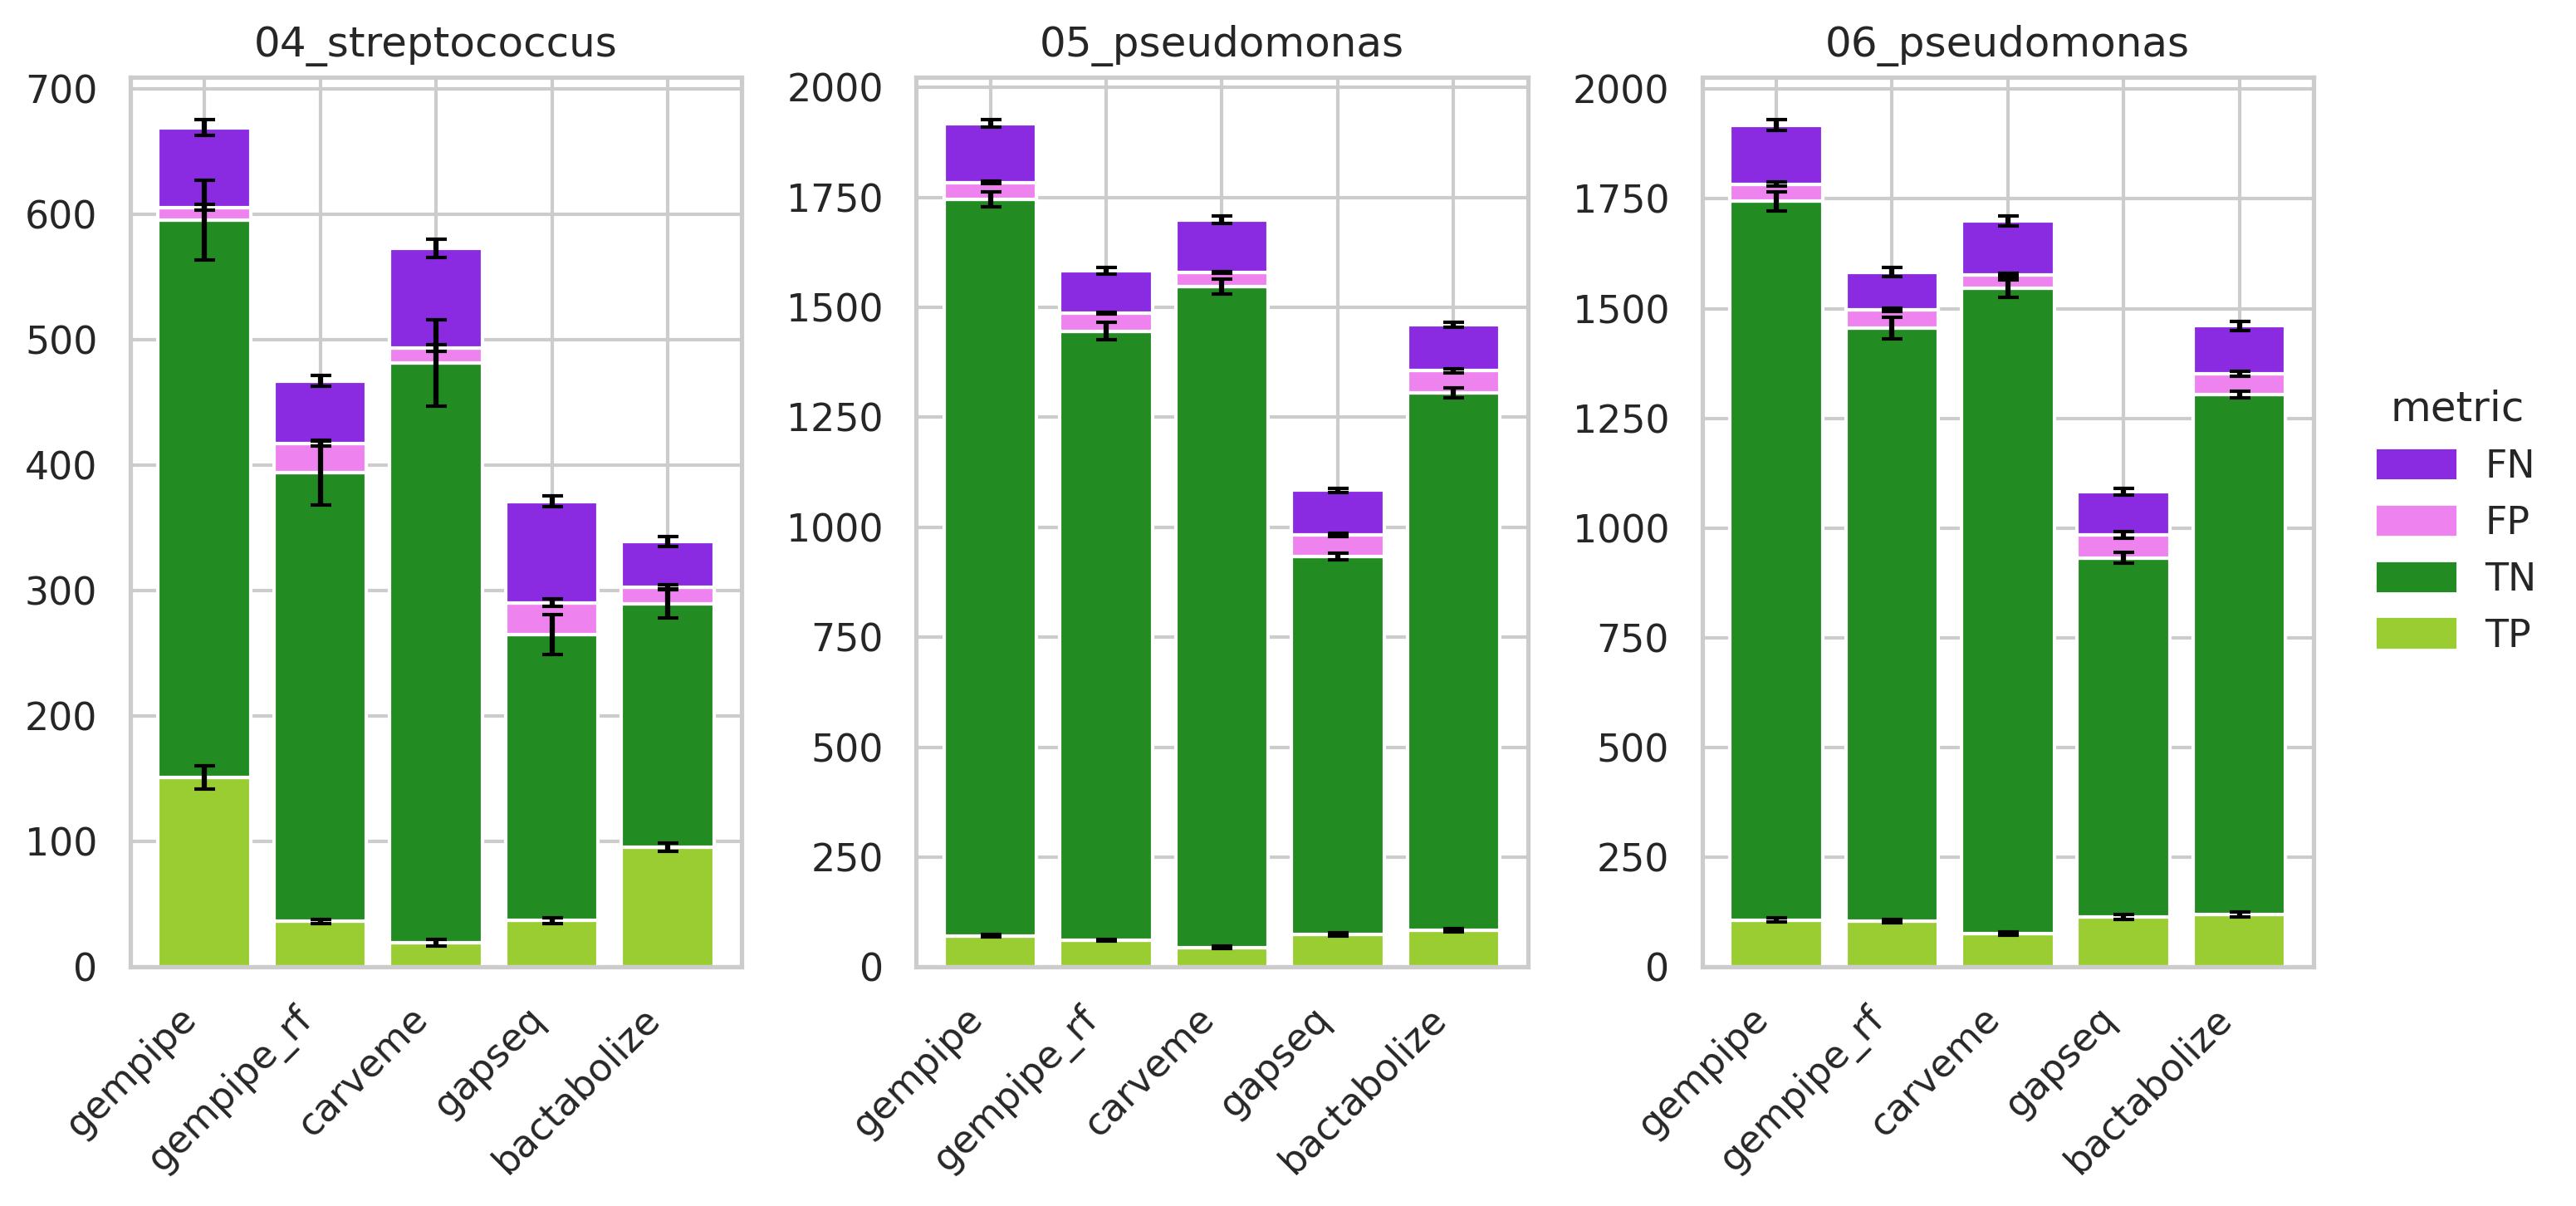

In [18]:
fig = plot_predictions_match(match_df, tool_colors, focus_on='gid', perc=False, common=False, std=True, exclude=[], alltools=True)
fig.savefig("figures/Figure 4B.png", dpi=300)

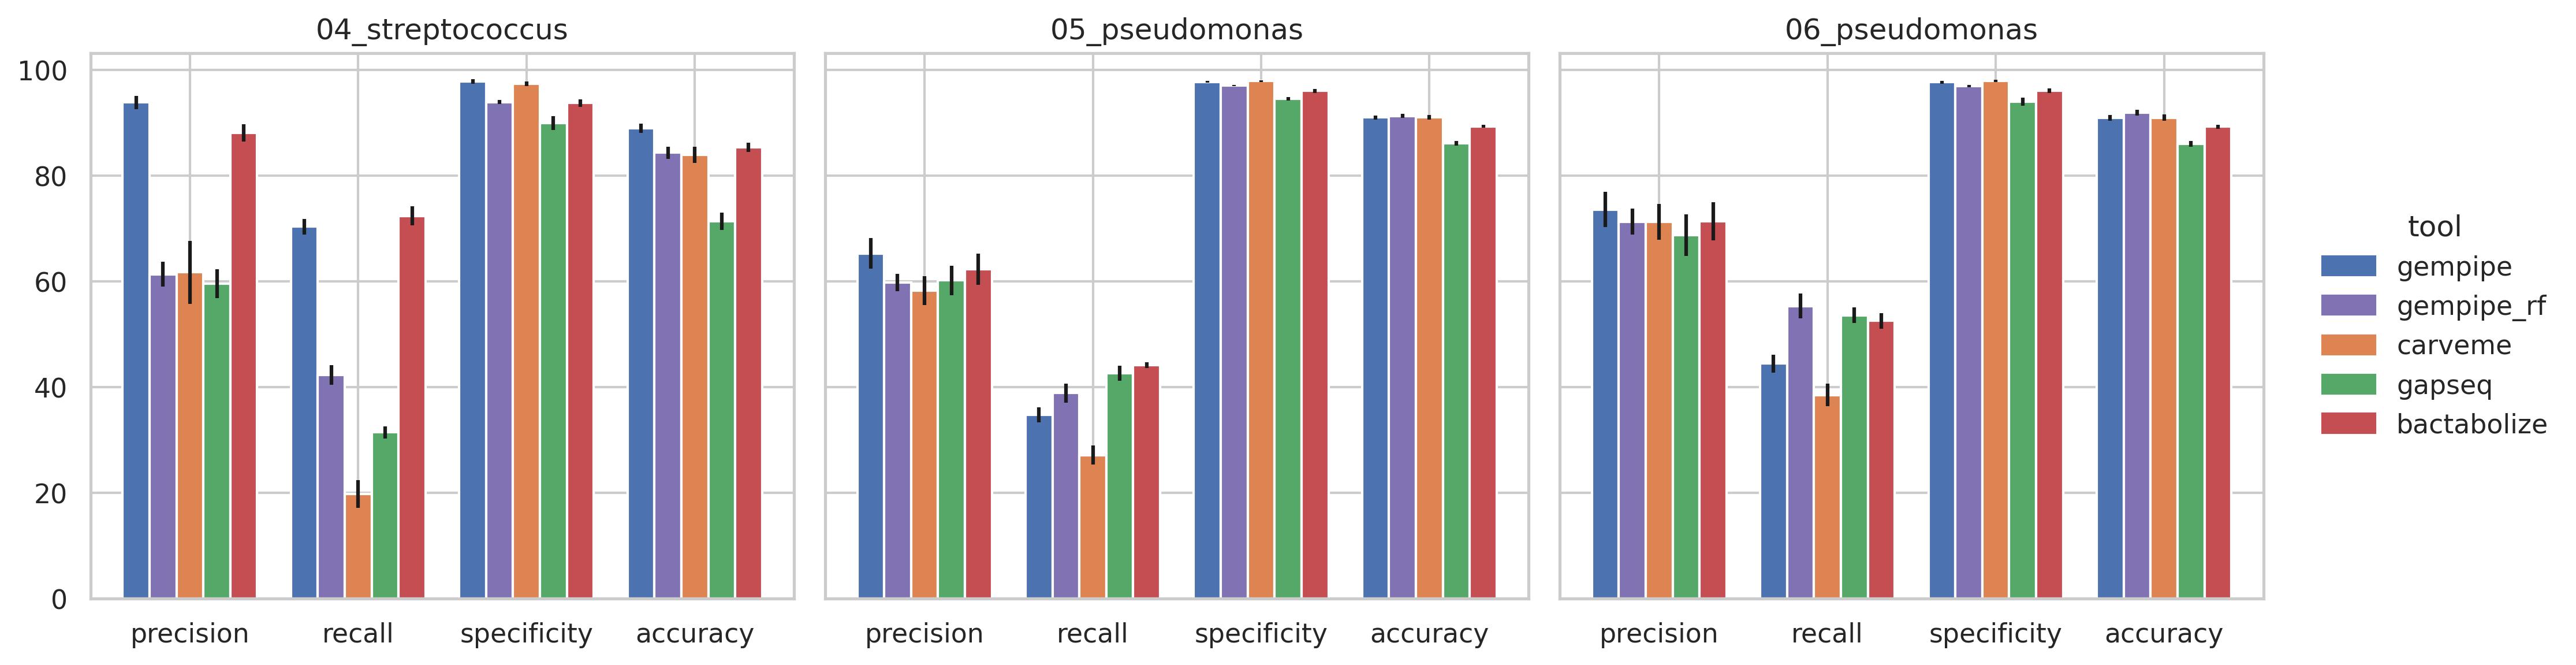

In [20]:
fig = plot_predictions_metrics(match_df, tool_colors, focus_on='gid', common=False, std=True, exclude=[], alltools=True)
fig.savefig("figures/Figure 4C.png", dpi=300)

In [21]:
from PIL import Image, ImageDraw, ImageFont

img_a = Image.open("figures/Figure 4A.png")
img_b = Image.open("figures/Figure 4B.png")
img_c = Image.open("figures/Figure 4C.png")

max_width = max(img_a.width, img_b.width, img_c.width)
total_height = img_a.height + img_b.height + img_c.height

# create new blank (white) image with the right dimensions
combined = Image.new("RGB", (max_width, total_height), "white")

# paste images, centered
x_offset_a = (max_width - img_a.width) // 2
x_offset_b = (max_width - img_b.width) // 2
x_offset_c = (max_width - img_c.width) // 2

combined.paste(img_a, (x_offset_a, 0))
combined.paste(img_b, (x_offset_b, img_a.height))
combined.paste(img_c, (x_offset_c, img_a.height + img_b.height))


# add labels
draw = ImageDraw.Draw(combined)
font = ImageFont.truetype(   # 60 wits well with 300dpi
    "/usr/share/fonts/truetype/liberation/LiberationSans-Bold.ttf", 60)


# add "A" at top-left of 2a
draw.text((10, 10), "A", font=font, fill="black")
# add "B" at top-left of 2b (relative to its starting y position)
draw.text((10, img_a.height + 10), "B", font=font, fill="black")
draw.text((10, img_a.height + img_b.height + 10), "C", font=font, fill="black")

combined.save("figures/Figure 4.png", dpi=(300, 300))

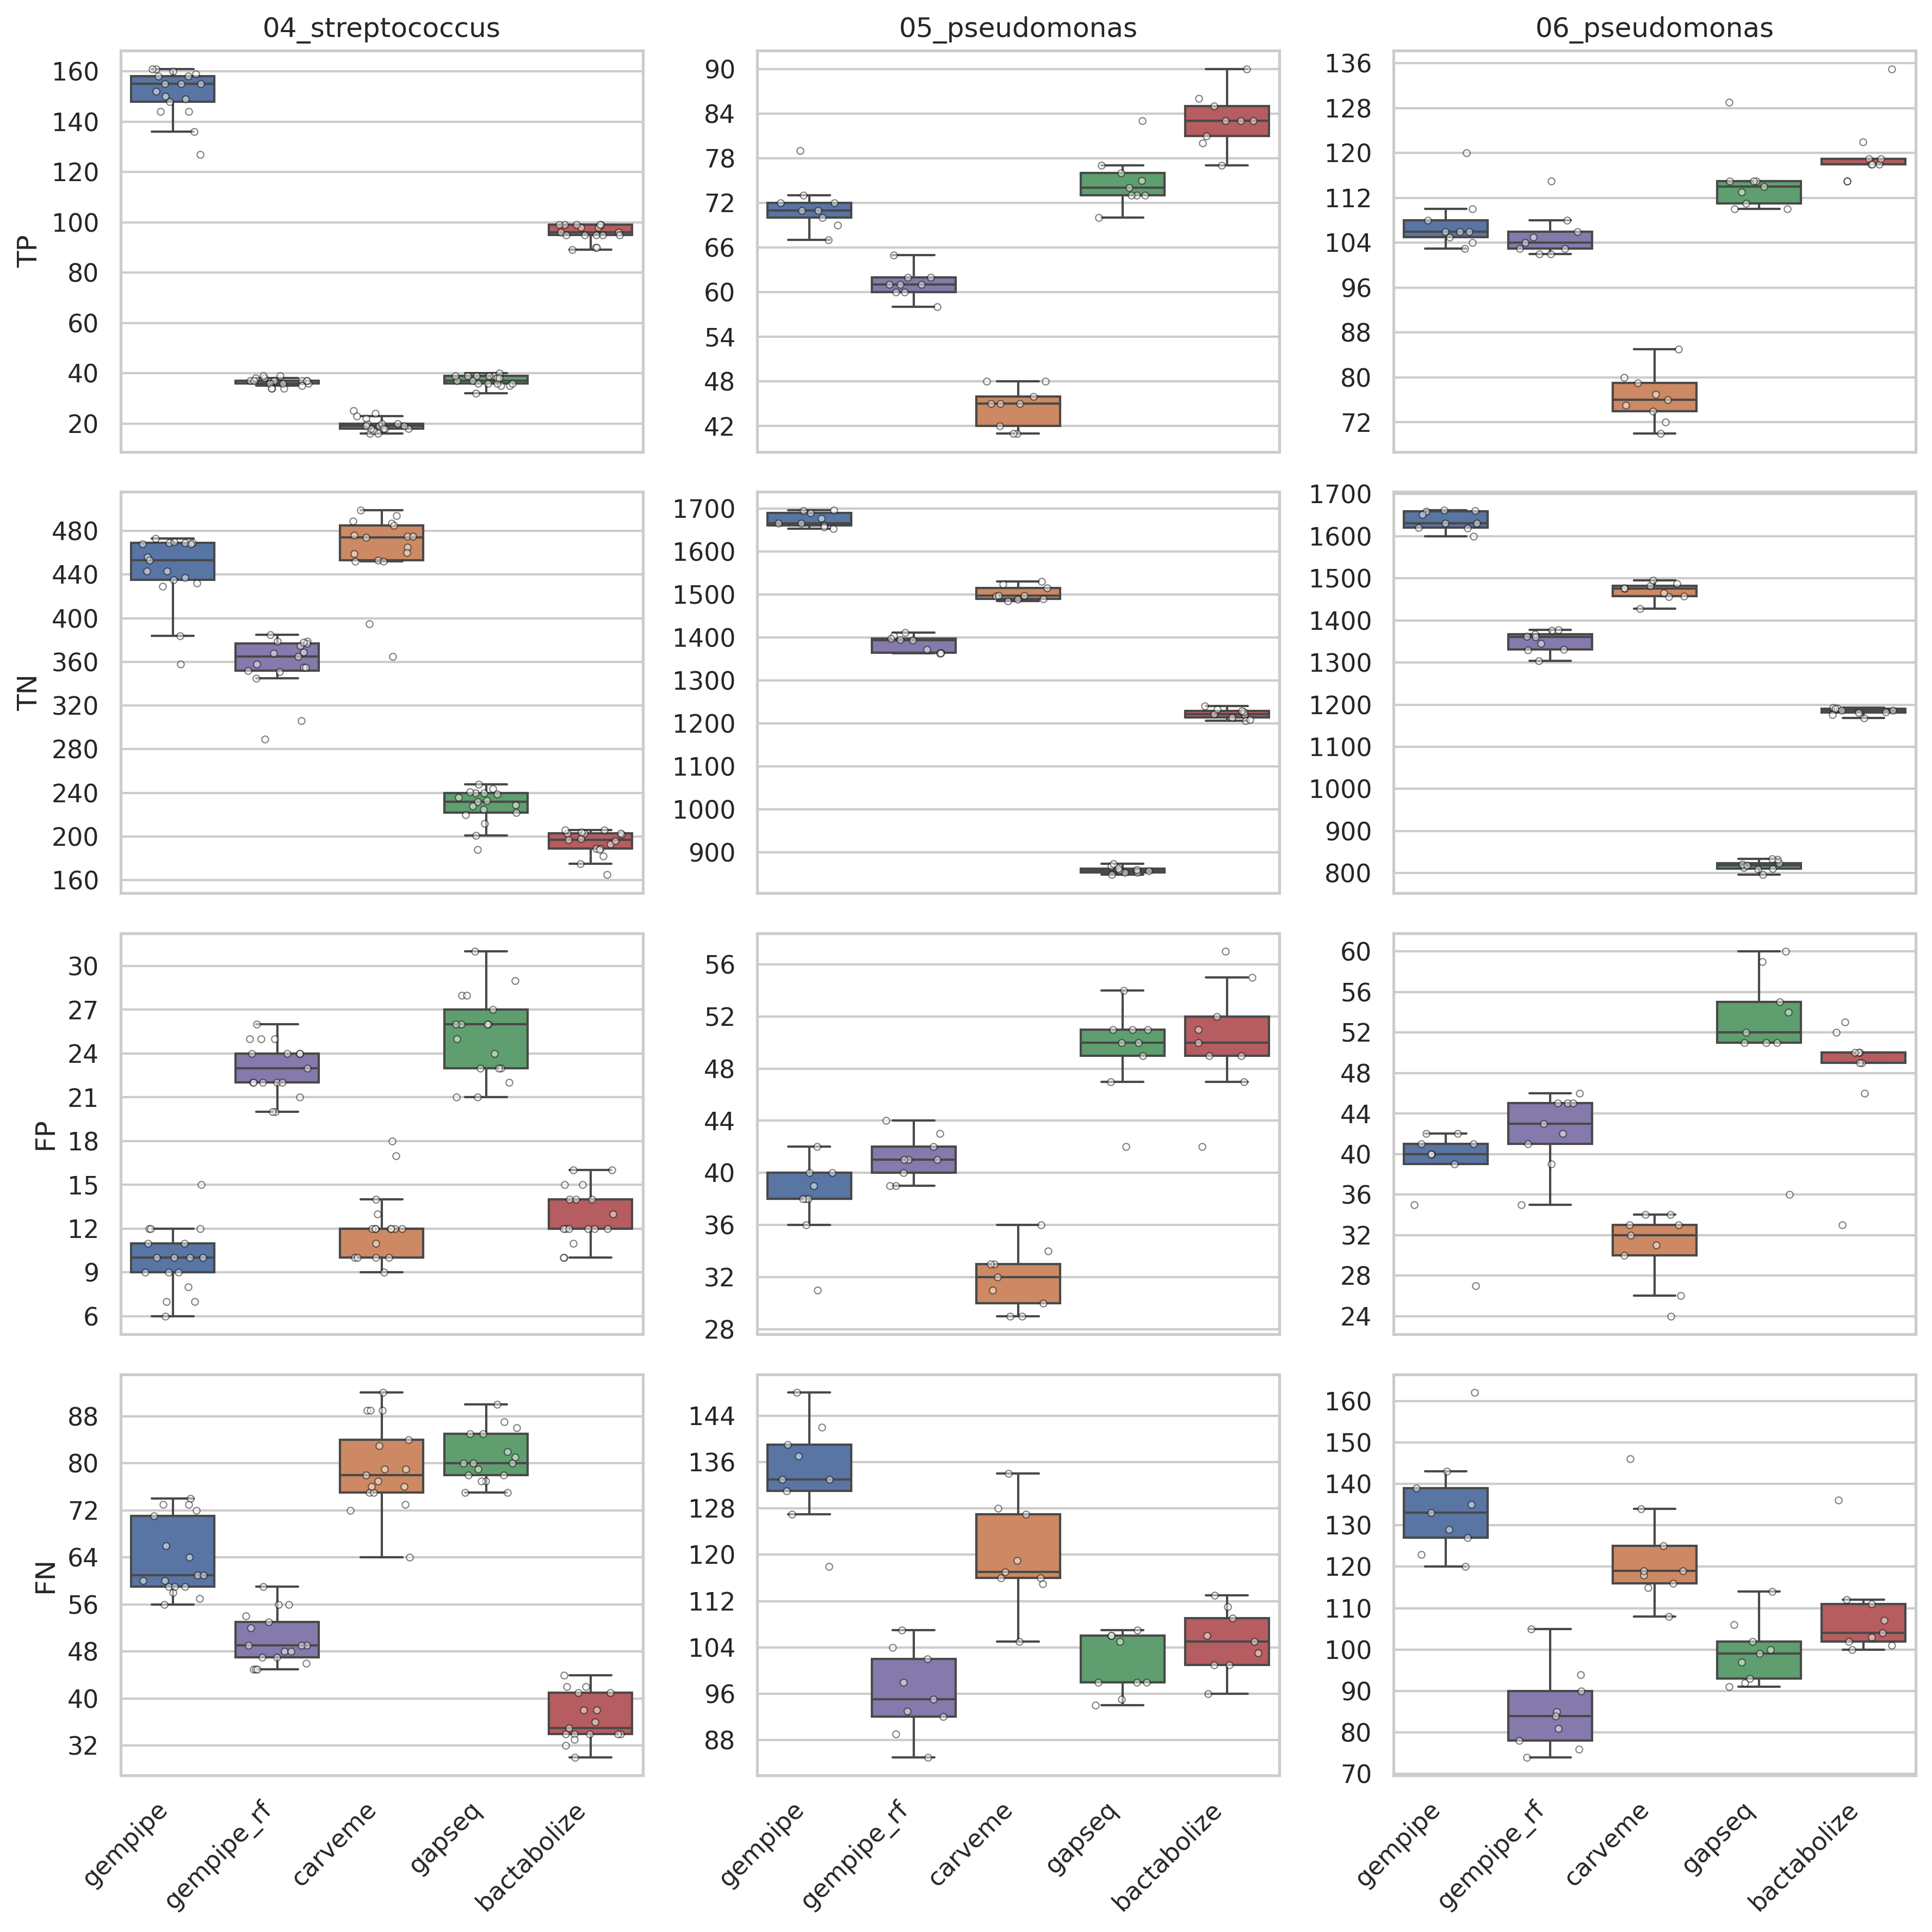

In [22]:
fig = plot_predictions_match2(match_df, tool_colors, focus_on='gid', common=False, exclude=[], alltools=True)